In [1]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-colorblind')    

import numpy as np
import datetime
import networkx as nx
import pandas as pd

from utils_graphs import *
from utils_data_vis import *

In [2]:
datasets_folder = "datasets/csvs/"
graphs_folder = "graphs/"
measures_folder = "measures/"
plots_folder = "plots/latex/"

# Horas críticas identificadas en el artículo de Beiró and Gandica et al.
HORA_CRITICA_NAT = "429624"
HORA_CRITICA_9N = "437037"
HORA_CRITICA_CH = "394717"

hour_window_nat = 1
hour_window_9n = 2
hour_window_ch = 2

limites = True

# AUTOSIMILITUD EN LAS REDES

## Redes normales (hashtags como nodos) 

In [3]:
# MAX_UMBRAL es el máximo K_T que se va a usar para generar subgrafos
MAX_UMBRAL = 200

dict_hora_nat_h = get_dict_hora_kt("nat", HORA_CRITICA_NAT, hour_window=hour_window_nat, node_type="hashtag", MAX_UMBRAL=MAX_UMBRAL)
dict_hora_9n_h = get_dict_hora_kt("9n", HORA_CRITICA_9N, hour_window=hour_window_9n, node_type="hashtag", MAX_UMBRAL=MAX_UMBRAL)
dict_hora_ch_h = get_dict_hora_kt("ch", HORA_CRITICA_CH, hour_window=hour_window_ch, node_type="hashtag", MAX_UMBRAL=MAX_UMBRAL)

100%|██████████| 200/200 [00:00<00:00, 1573.41it/s]


In [4]:
limit_kt_nat_h = 35
limit_kt_9n_h = 60
limit_kt_ch_h = 25

critical_kt_nat_h = 30
critical_kt_9n_h = 40
critical_kt_ch_h = 15

arr_kt_plot_nat_h = [0,2,4,8,9,10]
arr_kt_plot_9n_h = [0,10,15,20,25,30,35,40]
arr_kt_plot_ch_h = [0,7,9,11,13,15]



In [5]:
plfit_nat_h, arr_pdf_points_nat_h, arr_ccdf_points_nat_h = calc_degree_distribution(HORA_CRITICA_NAT, "nat/" + str(hour_window_nat) + '/', mode="h", measures_folder=measures_folder, arr_kt=arr_kt_plot_nat_h, exp=False, norm=True, read=False)
plfit_9n_h, arr_pdf_points_9n_h, arr_ccdf_points_9n_h = calc_degree_distribution(HORA_CRITICA_9N,  "9n/" + str(hour_window_9n) + '/', mode="h", measures_folder=measures_folder, arr_kt=arr_kt_plot_9n_h, exp=False, norm=True, read=False)
plfit_ch_h, arr_pdf_points_ch_h, arr_ccdf_points_ch_h = calc_degree_distribution(HORA_CRITICA_CH,  "ch/" + str(hour_window_ch) + '/', mode="h", measures_folder=measures_folder, arr_kt=arr_kt_plot_ch_h, exp=False, norm=True, read=False)

100%|██████████| 6/6 [00:00<00:00, 310.01it/s]


In [6]:
# Seleccionamos el fichero correspondiente a la manifestación social de la que queremos sacar la red y seleccionamos la hora que queremos estudiar
dict_thres_avg_clust_nat_h, dict_norm_int_deg_nat_h = calc_self_sim(HORA_CRITICA_NAT, MAX_UMBRAL, "nat/" + str(hour_window_nat) + '/')
dict_thres_avg_clust_9n_h, dict_norm_int_deg_9n_h = calc_self_sim(HORA_CRITICA_9N, MAX_UMBRAL, "9n/" + str(hour_window_9n) + '/')
dict_thres_avg_clust_ch_h, dict_norm_int_deg_ch_h = calc_self_sim(HORA_CRITICA_CH, MAX_UMBRAL, "ch/" + str(hour_window_ch) + '/')

100%|██████████| 200/200 [00:00<00:00, 260.36it/s]


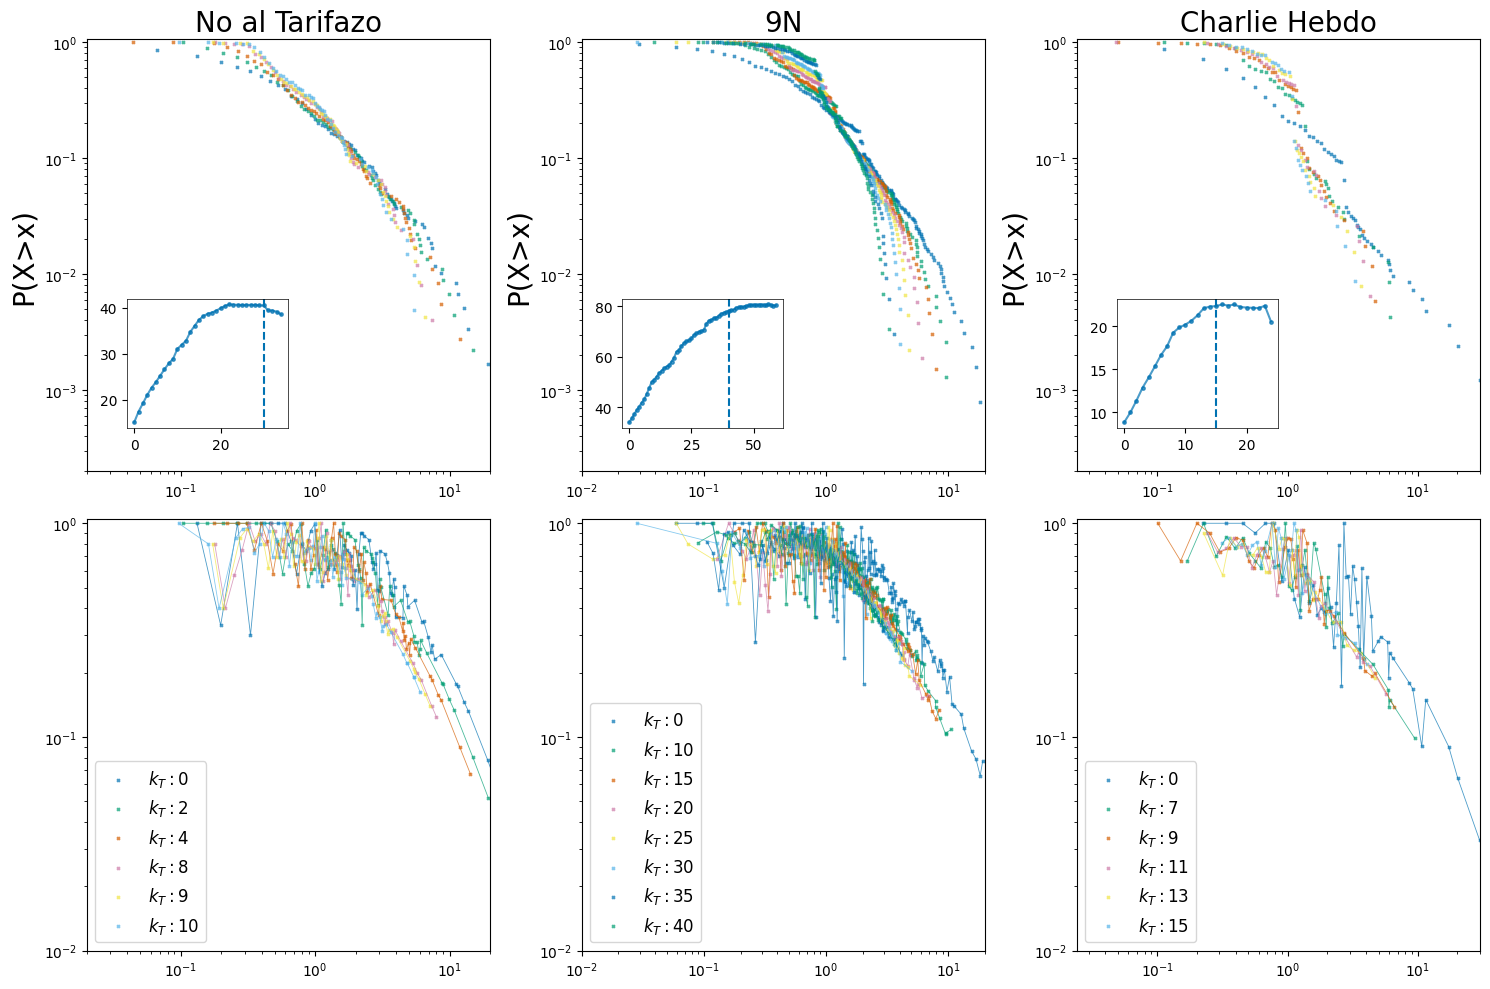

In [7]:
plt.style.use('seaborn-v0_8-colorblind')    

fig, axs = plt.subplots(2, 3)
axs = axs.flat
for ax in axs:  
	ax.set_facecolor("white")
fig.set_size_inches(15,10)

xlim_nat_h = (0.02, 20)
xlim_9n_h = (0.01, 20)
xlim_ch_h = (0.024, 30)

plot_pdf(axs[0], arr_ccdf_points_nat_h, arr_kt_plot_nat_h, title="No al Tarifazo", ylabel="P(X>x)", ylim=(0.0002, 1.05), xlim=xlim_nat_h)
ax0_inset = axs[0].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax0_inset, dict_hora_nat_h, limit_kt_nat_h, axvline=critical_kt_nat_h)

plot_pdf(axs[1], arr_ccdf_points_9n_h, arr_kt_plot_9n_h, title="9N", ylim=(0.0002, 1.05), xlim=xlim_9n_h)
ax1_inset = axs[1].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax1_inset, dict_hora_9n_h, limit_kt_9n_h, axvline=critical_kt_9n_h)

plot_pdf(axs[2], arr_ccdf_points_ch_h, arr_kt_plot_ch_h, title="Charlie Hebdo", ylim=(0.0002, 1.05), xlim=xlim_ch_h)
ax2_inset = axs[2].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax2_inset, dict_hora_ch_h, limit_kt_ch_h, axvline=critical_kt_ch_h)


plot_clust_ss(axs[3], arr_kt_plot_nat_h, dict_norm_int_deg_nat_h, xlim=xlim_nat_h, ylim=(0.01, 1.05))
plot_clust_ss(axs[4], arr_kt_plot_9n_h, dict_norm_int_deg_9n_h, xlim=xlim_9n_h, ylim=(0.01, 1.05))
plot_clust_ss(axs[5], arr_kt_plot_ch_h, dict_norm_int_deg_ch_h, xlim=xlim_ch_h, ylim=(0.01, 1.05))

plt.tight_layout()
plt.savefig(plots_folder + "CCDF_degree_self_sim_paper_hashtag.png")
plt.show()

## Grafos Filtrados

### Creación de los grafos filtrados

In [8]:
# Threshold empleado para cada manifestacion
umbral_nat = 3
umbral_9n = 5
umbral_ch = 3

# CREACIÓN DE LOS GRAFOS FILTRADOS
write_filtered_graph("nat", HORA_CRITICA_NAT, umbral_nat, graphs_folder, hour_window_nat)
write_filtered_graph("9n", HORA_CRITICA_9N, umbral_9n, graphs_folder, hour_window_9n)
write_filtered_graph("ch", HORA_CRITICA_CH, umbral_ch, graphs_folder, hour_window_ch)

Grafo nat:429624  (umbral 3) reducido a 19.16 % en nodos y  16.85 % en aristas.
Grafo 9n:437037  (umbral 5) reducido a 12.58 % en nodos y  7.1 % en aristas.
Grafo ch:394717  (umbral 3) reducido a 13.31 % en nodos y  7.4 % en aristas.


In [9]:
# MAX_UMBRAL es el máximo K_T que se va a usar para generar subgrafos
MAX_UMBRAL = 200
dict_hora_nat_f = get_dict_hora_kt("nat", HORA_CRITICA_NAT, hour_window=hour_window_nat, node_type="filtered", MAX_UMBRAL=MAX_UMBRAL, umbral_filt=umbral_nat)
dict_hora_9n_f = get_dict_hora_kt("9n", HORA_CRITICA_9N, hour_window=hour_window_9n, node_type="filtered", MAX_UMBRAL=MAX_UMBRAL, umbral_filt=umbral_9n)
dict_hora_ch_f = get_dict_hora_kt("ch", HORA_CRITICA_CH, hour_window=hour_window_ch, node_type="filtered", MAX_UMBRAL=MAX_UMBRAL, umbral_filt=umbral_ch)

 19%|█▉        | 38/200 [00:00<00:00, 12055.33it/s]


### Autosimilitud de redes filtradas y Resultados en otras ventanas temporales diferentes a la crítica

In [10]:
limit_kt_nat_f = 35
limit_kt_9n_f = 60
limit_kt_ch_f = 30

critical_kt_nat_f = 10
critical_kt_9n_f = 18
critical_kt_ch_f = 5

arr_kt_plot_nat_f = [0,2,4,6,8,10]
arr_kt_plot_9n_f = [0,3,6,9,12,15,18]
arr_kt_plot_ch_f = [0,1,2,3,4,5]


In [11]:
plfit_nat_f, arr_pdf_points_nat_f, arr_ccdf_points_nat_f = calc_degree_distribution(HORA_CRITICA_NAT, "nat/" + str(hour_window_nat) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_nat_f, thresh_filt=umbral_nat, norm=True, read=False)
plfit_9n_f, arr_pdf_points_9n_f, arr_ccdf_points_9n_f = calc_degree_distribution(HORA_CRITICA_9N, "9n/" + str(hour_window_9n) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_9n_f, thresh_filt=umbral_9n, norm=True, read=False)
plfit_ch_f, arr_pdf_points_ch_f, arr_ccdf_points_ch_f = calc_degree_distribution(HORA_CRITICA_CH, "ch/" + str(hour_window_ch) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_ch_f, thresh_filt=umbral_ch, norm=True, read=False)

100%|██████████| 6/6 [00:00<00:00, 953.68it/s]


Calculating best minimal value for power law fit


100%|██████████| 7/7 [00:00<00:00, 505.85it/s]


Calculating best minimal value for power law fit


100%|██████████| 6/6 [00:00<00:00, 3224.73it/s]

Calculating best minimal value for power law fit


In [12]:
# MAX_UMBRAL es el máximo K_T que vamos a usar para generar subgrafos
MAX_UMBRAL = 500
# Seleccionamos el fichero correspondiente a la manifestación social de la que queremos sacar la red y seleccionamos la hora que queremos estudiar
dict_thres_avg_clust_nat_f, dict_norm_int_deg_nat_f = calc_self_sim(HORA_CRITICA_NAT, MAX_UMBRAL, "nat/" + str(hour_window_nat) + '/', mode="f", thresh_filter=umbral_nat)
dict_thres_avg_clust_9n_f, dict_norm_int_deg_9n_f = calc_self_sim(HORA_CRITICA_9N, MAX_UMBRAL, "9n/" + str(hour_window_9n) + '/', mode="f", thresh_filter=umbral_9n)
dict_thres_avg_clust_ch_f, dict_norm_int_deg_ch_f = calc_self_sim(HORA_CRITICA_CH, MAX_UMBRAL, "ch/" + str(hour_window_ch) + '/', mode="f", thresh_filter=umbral_ch)

  8%|▊         | 38/500 [00:00<00:00, 1549.16it/s]


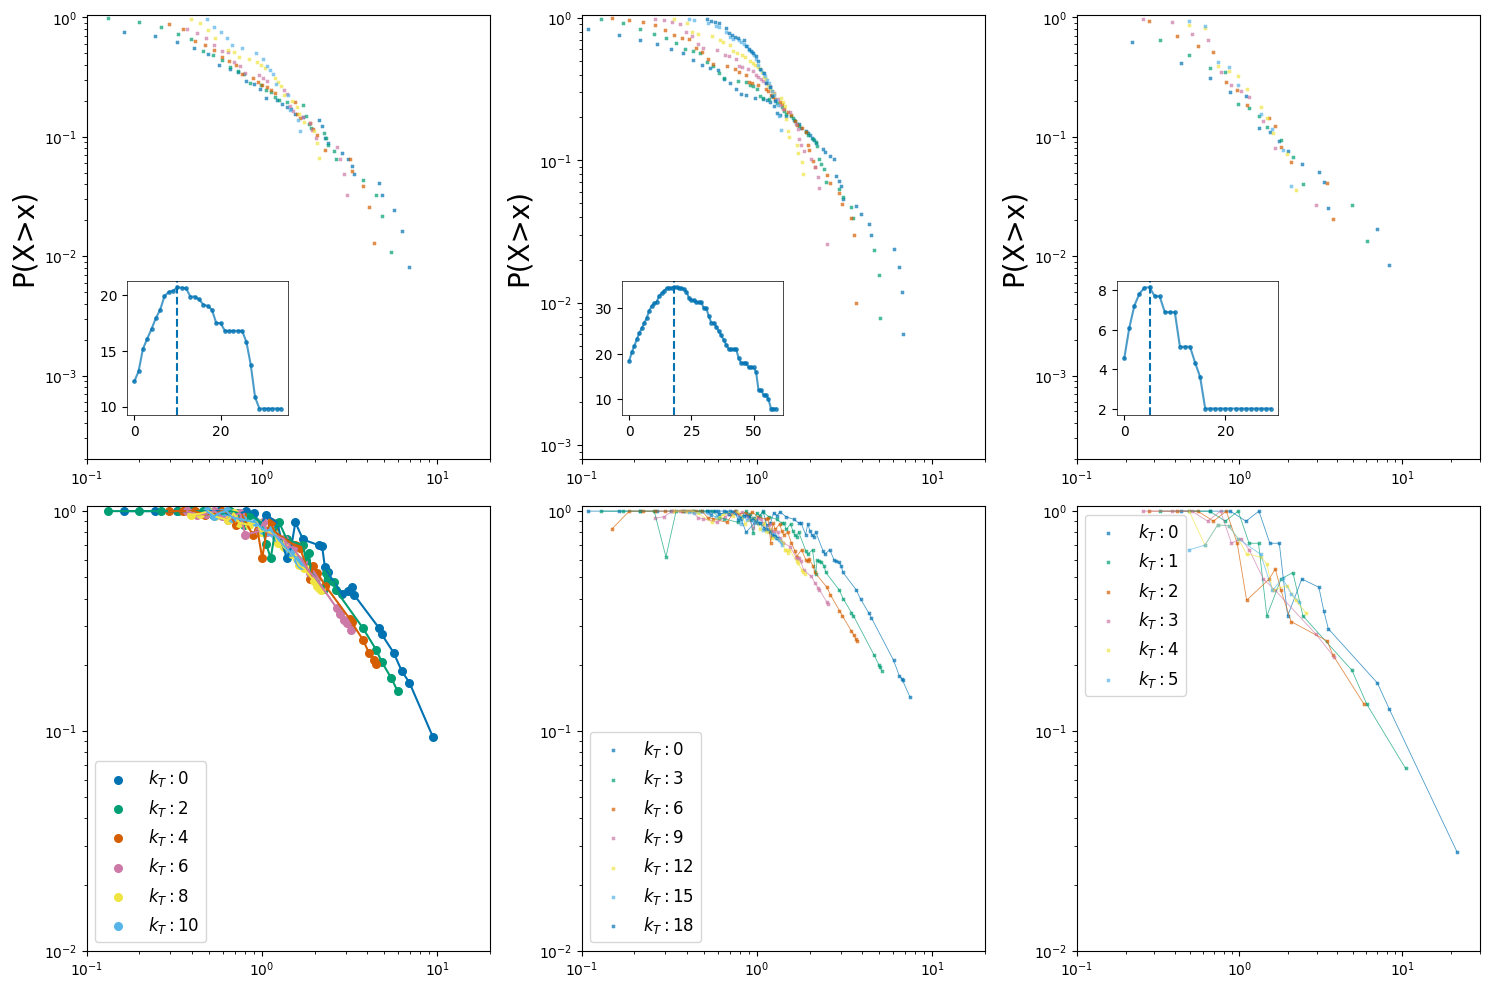

In [13]:
plt.style.use('seaborn-v0_8-colorblind')    

fig, axs = plt.subplots(2, 3)
axs = axs.flat
for ax in axs:  
	ax.set_facecolor("white")
fig.set_size_inches(15,10)

xlim_nat_f = (0.1, 20)
xlim_9n_f = (0.1, 20)
xlim_ch_f = (0.1, 30)

plot_pdf(axs[0], arr_ccdf_points_nat_f, arr_kt_plot_nat_f, ylabel="P(X>x)", ylim=(0.0002, 1.05), xlim=xlim_nat_f)
ax6_inset = axs[0].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax6_inset, dict_hora_nat_f, limit_kt_nat_f, axvline=critical_kt_nat_f)

plot_pdf(axs[1], arr_ccdf_points_9n_f, arr_kt_plot_9n_f, ylim=(0.0008, 1.05), xlim=xlim_9n_f)
ax7_inset = axs[1].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax7_inset, dict_hora_9n_f, limit_kt_9n_f, axvline=critical_kt_9n_f)

plot_pdf(axs[2], arr_ccdf_points_ch_f, arr_kt_plot_ch_f, ylim=(0.0002, 1.05), xlim=xlim_ch_f)
ax8_inset = axs[2].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax8_inset, dict_hora_ch_f, limit_kt_ch_f, axvline=critical_kt_ch_f)


plot_clust_ss(axs[3], arr_kt_plot_nat_f, dict_norm_int_deg_nat_f, xlim=xlim_nat_f, ylim=(0.01, 1.05), loc="lower left", linewidth=1.5, s=30, marker="o", alpha=1)
plot_clust_ss(axs[4], arr_kt_plot_9n_f, dict_norm_int_deg_9n_f, xlim=xlim_9n_f, ylim=(0.01, 1.05))
plot_clust_ss(axs[5], arr_kt_plot_ch_f, dict_norm_int_deg_ch_f, xlim=xlim_ch_f, ylim=(0.01, 1.05))


plt.tight_layout()
plt.savefig(plots_folder + "CCDF_degree_self_sim_paper_filtered.png")
plt.show()

## Grafos otras horas NO filtradas nat

In [14]:
otras_horas_nat = ["429552", "429576", "429600", "429624", "429648", "429672", "429696", "429636"]

limit_kt_nat_o = 60
arr_kt_plot_nat_o = [0,2,4,6,8,10]


In [15]:
arr_dicts_avg_clust_nat_o = []
arr_dicts_norm_int_deg_nat_o = []
arr_ccdfs_points_nat_o = []
arr_dicts_hora_nat_o = []
arr_dicts_thres_avg_clust_nat_o = []
for hora in otras_horas_nat:

	dict_thres_avg_clust_nat_o, dict_norm_int_deg_nat_o = calc_self_sim(hora, MAX_UMBRAL, "nat/" + str(hour_window_nat) + '/', mode="h")
	plfit_nat_o, arr_pdf_points_nat_o, arr_ccdf_points_nat_o = calc_degree_distribution(hora, "nat/" + str(hour_window_nat) + '/', mode="h", arr_kt=arr_kt_plot_nat_o,read=False, exp=False, norm=True)
	dict_hora_nat_o = get_dict_hora_kt("nat", hora, hour_window=hour_window_nat, node_type="hashtag", MAX_UMBRAL=MAX_UMBRAL)

	arr_dicts_avg_clust_nat_o.append(dict_thres_avg_clust_nat_o)
	arr_dicts_norm_int_deg_nat_o.append(dict_norm_int_deg_nat_o)
	arr_ccdfs_points_nat_o.append(arr_ccdf_points_nat_o)
	arr_dicts_hora_nat_o.append(dict_hora_nat_o)

 19%|█▉        | 97/500 [00:00<00:00, 696.41it/s]


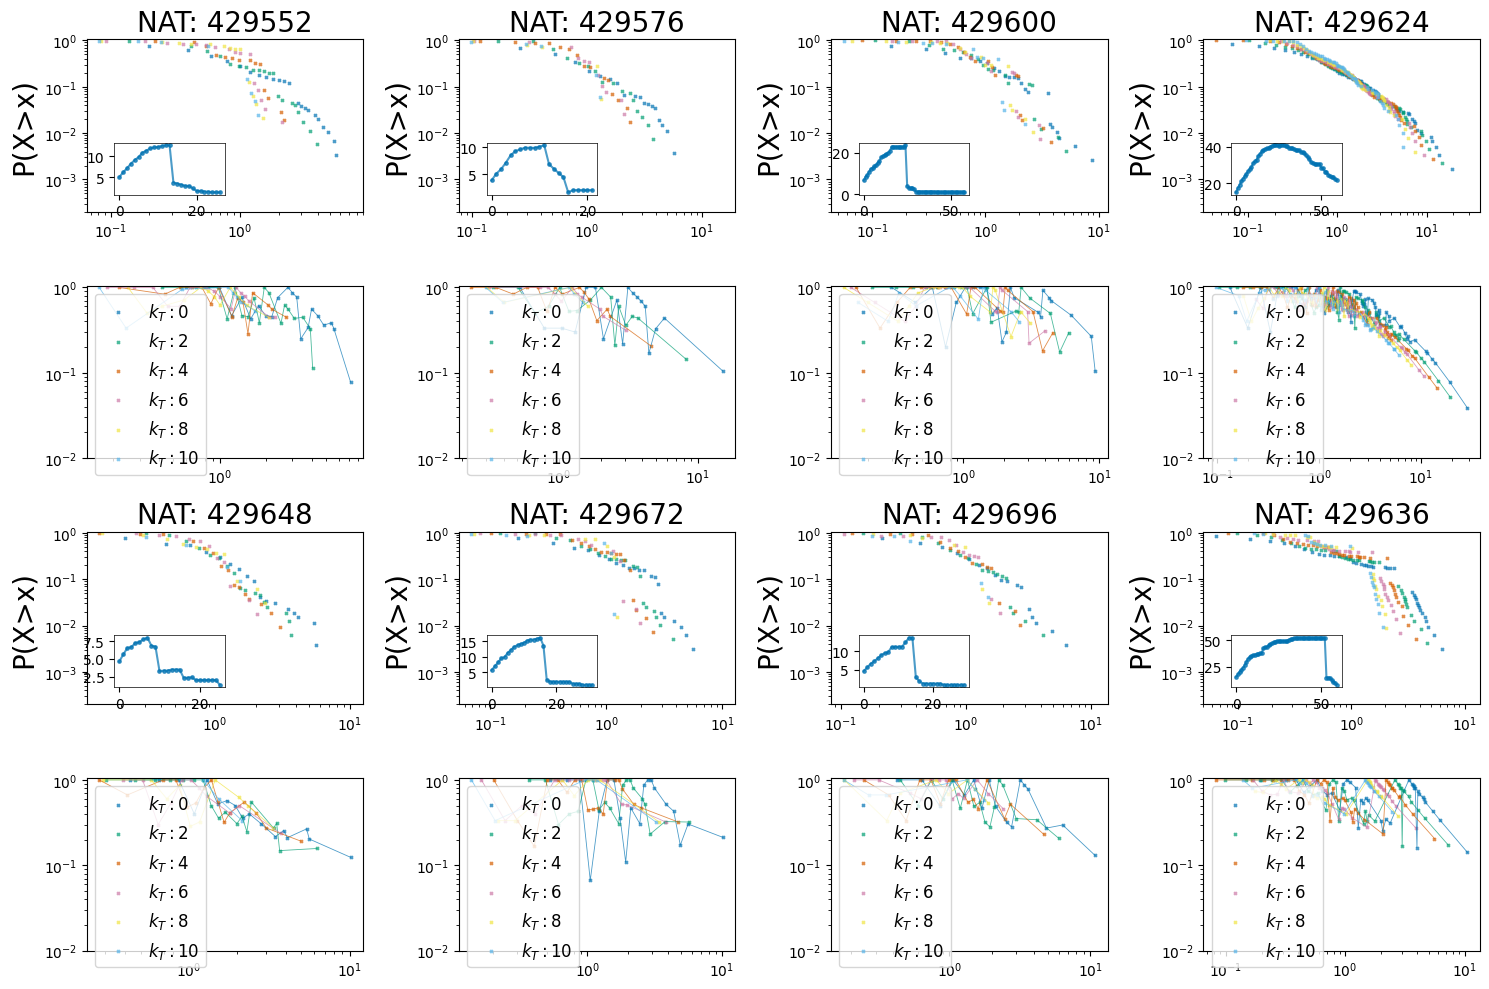

In [16]:
plt.style.use('seaborn-v0_8-colorblind')    

fig, axs = plt.subplots(4, 4)
fig.set_size_inches(15,10)

xlim_nat_o = (0.1, 20)
for i, rax in enumerate(axs[::2]):
	index = i*2
	for j, ax in enumerate(rax):
		plot_pdf(axs[index][j], arr_ccdfs_points_nat_o[i*len(rax)+j], arr_kt_plot_nat_o, ylabel="P(X>x)", ylim=(0.0002, 1.05),  title=f"NAT: {otras_horas_nat[i*len(rax)+j]}")
		ax_inset = axs[index][j].inset_axes([0.1, 0.1, 0.4, 0.3])
		plot_avg_deg(ax_inset, arr_dicts_hora_nat_o[i*len(rax)+j], limit_kt_nat_o)
		plot_clust_ss(axs[index+1][j], arr_kt_plot_nat_o, arr_dicts_norm_int_deg_nat_o[i*len(rax)+j], ylim=(0.01, 1.05))

plt.tight_layout()
plt.savefig(plots_folder + "CCDF_degree_self_sim_otras_horas.png")
plt.show()

He probado a filtrarlos, pero en la mayoría de casos, se tratan de grafos tan pequeños que no hay valores para plotear

## Disparity filter with multiple confidence levels

### Redes originales

In [17]:
def convertir_file(hora, filtered=False, umbral=None):
	if not filtered:
		G = nx.read_gexf(f"graphs/nodes_hashtag/nat/1/{hora}.gexf")
		nombre_output = f"disparity_filter/puntos/{hora}.csv"
	else:
		G = nx.read_gexf(f"graphs/nodes_filtered/{umbral}/nat/1/{hora}.gexf")
		nombre_output = f"disparity_filter/puntos/{hora}_filt.csv"
	print(G.number_of_nodes(), G.number_of_edges(), nombre_output)
	with open(nombre_output, "w") as f:
		arr_edges = ""
		for orig, dst, we in G.edges(data=True):
			if "weight" not in G[orig][dst].keys():
				print(orig, dst)
			peso = int(G[orig][dst]["weight"])
			arr_edges = arr_edges + f"{orig},{dst},{peso} \n"
		f.write(arr_edges)
	

In [18]:
arr_kt_plot_nat_d = [0,1,2,4,6,8,10]
horas = ["429552", "429576", "429600", "429624", "429648", "429672", "429696", "429636"]
horas = ["429624"]
for hora in tqdm(horas):
	convertir_file(hora)
	filename_input = f"disparity_filter/puntos/{hora}.csv"
	filename_output = f"disparity_filter/puntos/{hora}_conf_all"
	backbone_confidence(filename_input, filename_output + '.csv')

  0%|          | 0/1 [00:00<?, ?it/s]

642 4470 disparity_filter/puntos/429624.csv


100%|██████████| 1/1 [00:00<00:00,  1.17it/s]


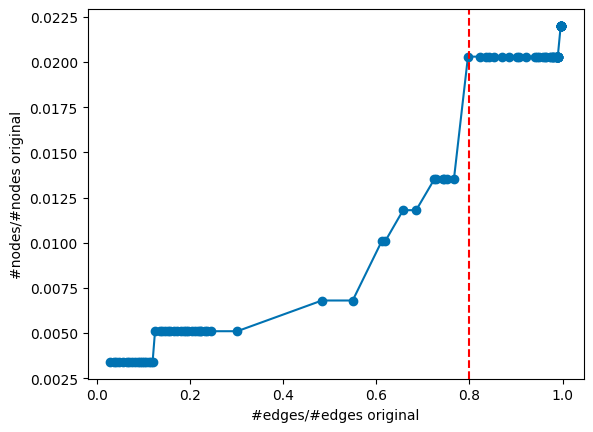

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Cargar datos desde archivo
datos = np.loadtxt("disparity_filter/puntos/429624_conf_all.csv")

x = datos[:, 3]  
y = datos[:, 2]  

plt.plot(x, y, marker='o')
plt.axvline(x=0.8, color='red', linestyle='--')
plt.xlabel('#edges/#edges original')
plt.ylabel('#nodes/#nodes original')
plt.show()


In [20]:
arr_kt_plot_nat_d = [0,1,2,4,6,8,10]
horas = ["429624"]
for hora in tqdm(horas):
	convertir_file(hora)
	filename_input = f"disparity_filter/puntos/{hora}.csv"
	filename_output = f"disparity_filter/puntos/{hora}_conf"
	backbone(filename_input, filename_output + '49.csv', wconfidence=0.49)


	G = nx.Graph()  # Usa nx.DiGraph() si necesitas que sea dirigido
	with open(f"disparity_filter/puntos/{hora}_conf49.csv", "r") as f:
		for line in f:
			source, target, weight = line.strip().split()
			G.add_edge(int(source), int(target), weight=float(weight))

	nx.write_gexf(G, f"graphs/nodes_disparity/nat/1/{hora}.gexf")


	dict_hora_nat_d = get_dict_hora_kt("nat", hora, hour_window=hour_window_nat, node_type="disparity", MAX_UMBRAL=200)

	plfit_nat_d, arr_pdf_points_nat_d, arr_ccdf_points_nat_d = calc_degree_distribution(hora, "nat/" + str(hour_window_nat) + '/', mode="d", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_nat_d, norm=True)

	dict_thres_avg_clust_nat_h_d, dict_norm_int_deg_nat_h_d = calc_self_sim(hora, 200, "nat/" + str(hour_window_nat) + '/', mode="d")

  0%|          | 0/1 [00:00<?, ?it/s]

642 4470 disparity_filter/puntos/429624.csv
fraction of weight in backbone= 0.9213615023474179 disparity_filter/puntos/429624_conf49.csv


100%|██████████| 7/7 [00:00<00:00, 51690.37it/s]


Calculating best minimal value for power law fit


100%|██████████| 1/1 [00:01<00:00,  1.30s/it]


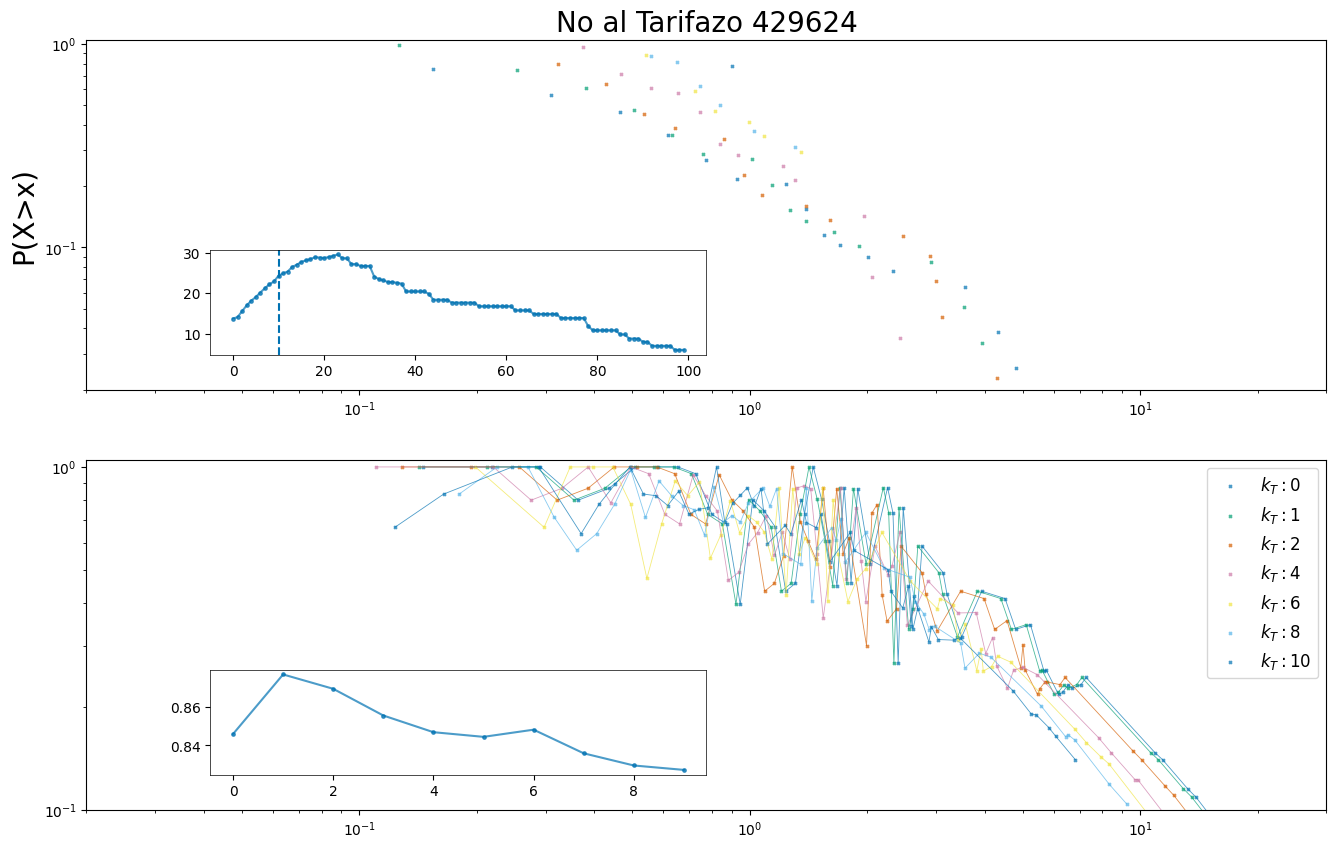

In [21]:

plt.style.use('seaborn-v0_8-colorblind')    

fig, axs = plt.subplots(2, 1)
axs = axs.flat
for ax in axs:  
	ax.set_facecolor("white")
fig.set_size_inches(16,10)

plot_pdf(axs[0], arr_ccdf_points_nat_d, arr_kt_plot_nat_d, title=f"No al Tarifazo {horas[0]}", ylabel="P(X>x)", ylim=(0.02, 1.05), xlim = (0.02, 30))
ax0_inset = axs[0].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax0_inset, dict_hora_nat_d, 100, axvline=10)


plot_clust_ss(axs[1], arr_kt_plot_nat_d, dict_norm_int_deg_nat_h_d, xlim=(0.02, 30), ylim=(0.1, 1.05), legend=True)
ax3_inset = axs[1].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax3_inset, dict_thres_avg_clust_nat_h_d, 10, dot_size=6)

plt.savefig(plots_folder + "self_sim_disparity.png")
plt.show()

### Redes filtradas

In [22]:
arr_kt_plot_nat_d = [0,1,2,4,6,8,10]
horas = ["429624"]
for hora in tqdm(horas):
	convertir_file(hora, filtered=True, umbral=umbral_nat)
	filename_input = f"disparity_filter/puntos/{hora}_filt.csv"
	filename_output = f"disparity_filter/puntos/{hora}_filt_conf_all"
	backbone_confidence(filename_input, filename_output + '.csv')

100%|██████████| 1/1 [00:00<00:00,  6.88it/s]

123 753 disparity_filter/puntos/429624_filt.csv


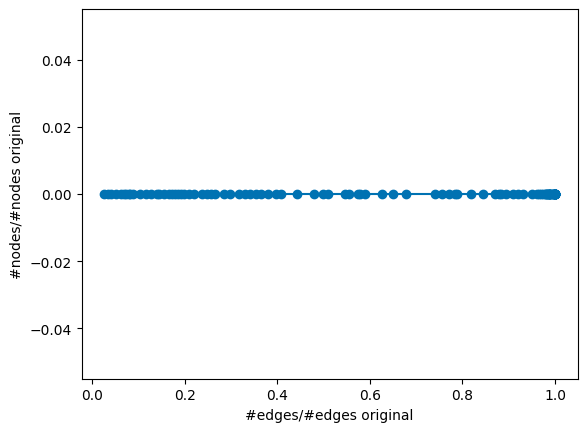

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Cargar datos desde archivo
datos_f_d = np.loadtxt("disparity_filter/puntos/429624_filt_conf_all.csv")

x = datos_f_d[:, 3]  
y = datos_f_d[:, 2]  

plt.plot(x, y, marker='o')
#plt.axvline(x=0.8, color='red', linestyle='--')
plt.xlabel('#edges/#edges original')
plt.ylabel('#nodes/#nodes original')
plt.show()


In [24]:
arr_kt_plot_nat_f_d = [0,1,2,4,6,8,10]
horas = ["429624"]
for hora in tqdm(horas):
	convertir_file(hora)
	filename_input = f"disparity_filter/puntos/{hora}_filt.csv"
	filename_output = f"disparity_filter/puntos/{hora}_filt_conf"
	backbone(filename_input, filename_output + '49.csv', wconfidence=0.49)


	G = nx.Graph()  # Usa nx.DiGraph() si necesitas que sea dirigido
	with open(f"disparity_filter/puntos/{hora}_filt_conf49.csv", "r") as f:
		for line in f:
			source, target, weight = line.strip().split()
			G.add_edge(int(source), int(target), weight=float(weight))

	nx.write_gexf(G, f"graphs/nodes_disparity/nat/1/{hora}_filt.gexf")

"""	dict_hora_nat_f_d = get_dict_hora_kt("nat", hora, hour_window=hour_window_nat, node_type="disparity", MAX_UMBRAL=200)

	plfit_nat_f_d, arr_pdf_points_nat_f_d, arr_ccdf_points_nat_f_d = calc_degree_distribution(hora, "nat/" + str(hour_window_nat) + '/', mode="d", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_nat_f_d, norm=True)

	dict_thres_avg_clust_nat_f_d, dict_norm_int_deg_nat_f_d = calc_self_sim(hora, 200, "nat/" + str(hour_window_nat) + '/', mode="d")"""
#TBD Adaptar estas funciones (si precisa y tiene sentido para poder emplear el filtrado por disparidad-->Re enrutar adecuadamente el path)


100%|██████████| 1/1 [00:00<00:00, 10.86it/s]

642 4470 disparity_filter/puntos/429624.csv
fraction of weight in backbone= 0.908394965615674 disparity_filter/puntos/429624_filt_conf49.csv


'\tdict_hora_nat_f_d = get_dict_hora_kt("nat", hora, hour_window=hour_window_nat, node_type="disparity", MAX_UMBRAL=200)\n\n\tplfit_nat_f_d, arr_pdf_points_nat_f_d, arr_ccdf_points_nat_f_d = calc_degree_distribution(hora, "nat/" + str(hour_window_nat) + \'/\', mode="d", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_nat_f_d, norm=True)\n\n\tdict_thres_avg_clust_nat_f_d, dict_norm_int_deg_nat_f_d = calc_self_sim(hora, 200, "nat/" + str(hour_window_nat) + \'/\', mode="d")'

In [25]:
"""
plt.style.use('seaborn-v0_8-colorblind')    

fig, axs = plt.subplots(2, 1)
axs = axs.flat
for ax in axs:  
	ax.set_facecolor("white")
fig.set_size_inches(16,10)

plot_pdf(axs[0], arr_ccdf_points_nat_f_d, arr_kt_plot_nat_f_d, title=f"No al Tarifazo {horas[0]}", ylabel="P(X>x)", ylim=(0.02, 1.05), xlim = (0.02, 30))
ax0_inset = axs[0].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax0_inset, dict_hora_nat_f_d, 100, axvline=10)


plot_clust_ss(axs[1], arr_kt_plot_nat_f_d, dict_norm_int_deg_nat_f_d, xlim=(0.02, 30), ylim=(0.1, 1.05), legend=True)
ax3_inset = axs[1].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax3_inset, dict_thres_avg_clust_nat_f_d, 10, dot_size=6)

plt.savefig(plots_folder + "self_sim_disparity_filt.png")
plt.show()"""

'\nplt.style.use(\'seaborn-v0_8-colorblind\')    \n\nfig, axs = plt.subplots(2, 1)\naxs = axs.flat\nfor ax in axs:  \n\tax.set_facecolor("white")\nfig.set_size_inches(16,10)\n\nplot_pdf(axs[0], arr_ccdf_points_nat_f_d, arr_kt_plot_nat_f_d, title=f"No al Tarifazo {horas[0]}", ylabel="P(X>x)", ylim=(0.02, 1.05), xlim = (0.02, 30))\nax0_inset = axs[0].inset_axes([0.1, 0.1, 0.4, 0.3])\nplot_avg_deg(ax0_inset, dict_hora_nat_f_d, 100, axvline=10)\n\n\nplot_clust_ss(axs[1], arr_kt_plot_nat_f_d, dict_norm_int_deg_nat_f_d, xlim=(0.02, 30), ylim=(0.1, 1.05), legend=True)\nax3_inset = axs[1].inset_axes([0.1, 0.1, 0.4, 0.3])\nplot_avg_deg(ax3_inset, dict_thres_avg_clust_nat_f_d, 10, dot_size=6)\n\nplt.savefig(plots_folder + "self_sim_disparity_filt.png")\nplt.show()'

## Exponential binning

### Redes originales

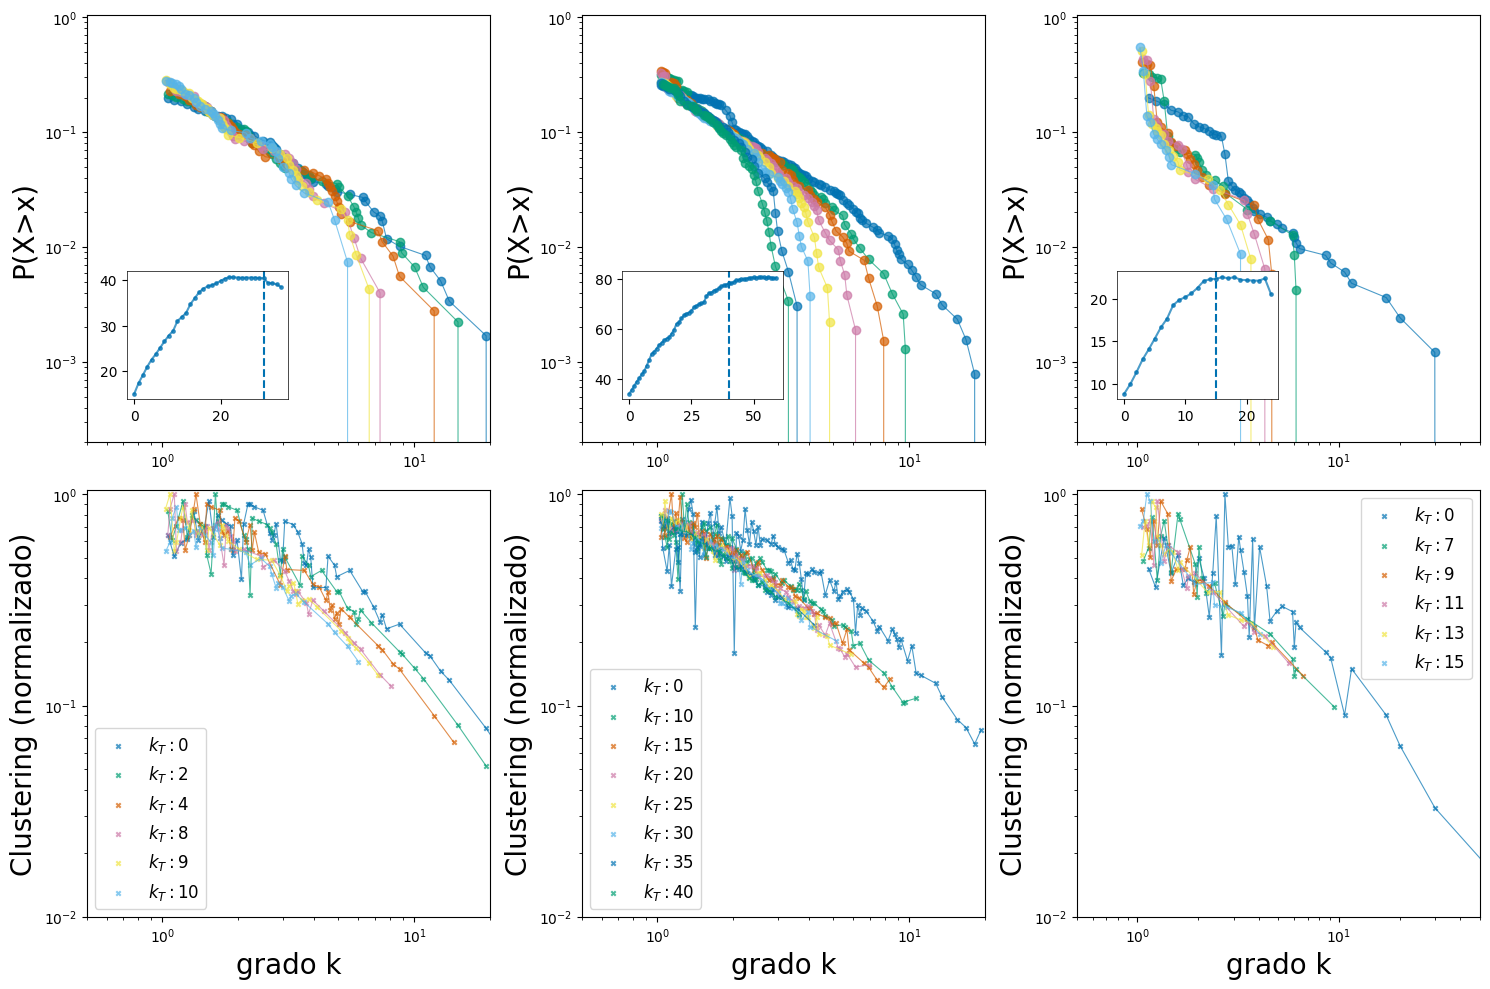

In [26]:
plt.style.use('seaborn-v0_8-colorblind')    

fig, axs = plt.subplots(2, 3)
axs = axs.flat
for ax in axs:  
	ax.set_facecolor("white")
fig.set_size_inches(15,10)

xlim_nat_h_e = (0.5, 20)
xlim_9n_h_e = (0.5, 20)
xlim_ch_h_e = (0.5, 50)

plot_pdf_expbin(axs[0], arr_ccdf_points_nat_h, arr_kt_plot_nat_h,
                aa=1.02, ylabel="P(X>x)", ylim=(0.0002, 1.05), xlim=xlim_nat_h_e,
                marker="o", alpha=0.7, dot_size=6, line=True, normalize=False)
ax0_inset = axs[0].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax0_inset, dict_hora_nat_h, limit_kt_nat_h, axvline=critical_kt_nat_h)

plot_pdf_expbin(axs[1], arr_ccdf_points_9n_h, arr_kt_plot_9n_h,
                aa=1.02, ylabel="P(X>x)", ylim=(0.0002, 1.05), xlim=xlim_9n_h_e,
                marker="o", alpha=0.7, dot_size=6, line=True, normalize=False)
ax1_inset = axs[1].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax1_inset, dict_hora_9n_h, limit_kt_9n_h, axvline=critical_kt_9n_h)

plot_pdf_expbin(axs[2], arr_ccdf_points_ch_h, arr_kt_plot_ch_h,
                aa=1.02, ylabel="P(X>x)", ylim=(0.0002, 1.05), xlim=xlim_ch_h_e,
                marker="o", alpha=0.7, dot_size=6, line=True, normalize=False)
ax2_inset = axs[2].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax2_inset, dict_hora_ch_h, limit_kt_ch_h, axvline=critical_kt_ch_h)


plot_clust_ss_expbin(axs[3], arr_kt_plot_nat_h, dict_norm_int_deg_nat_h,
                     aa=1.02, xlim=xlim_nat_h_e, ylim=(0.01, 1.05),
                     alpha=0.7, marker="x", linewidth=0.8, s=10,
                     ylabel="Clustering (normalizado)", xlabel="grado k")

plot_clust_ss_expbin(axs[4], arr_kt_plot_9n_h, dict_norm_int_deg_9n_h,
                     aa=1.02, xlim=xlim_9n_h_e, ylim=(0.01, 1.05),
                     alpha=0.7, marker="x", linewidth=0.8, s=10,
                     ylabel="Clustering (normalizado)", xlabel="grado k")

plot_clust_ss_expbin(axs[5], arr_kt_plot_ch_h, dict_norm_int_deg_ch_h,
                     aa=1.02, xlim=xlim_ch_h_e, ylim=(0.01, 1.05),
                     alpha=0.7, marker="x", linewidth=0.8, s=10,
                     ylabel="Clustering (normalizado)", xlabel="grado k")


plt.tight_layout()
plt.savefig(plots_folder + "self_sim_exponential.png")
plt.show()

### Redes filtradas

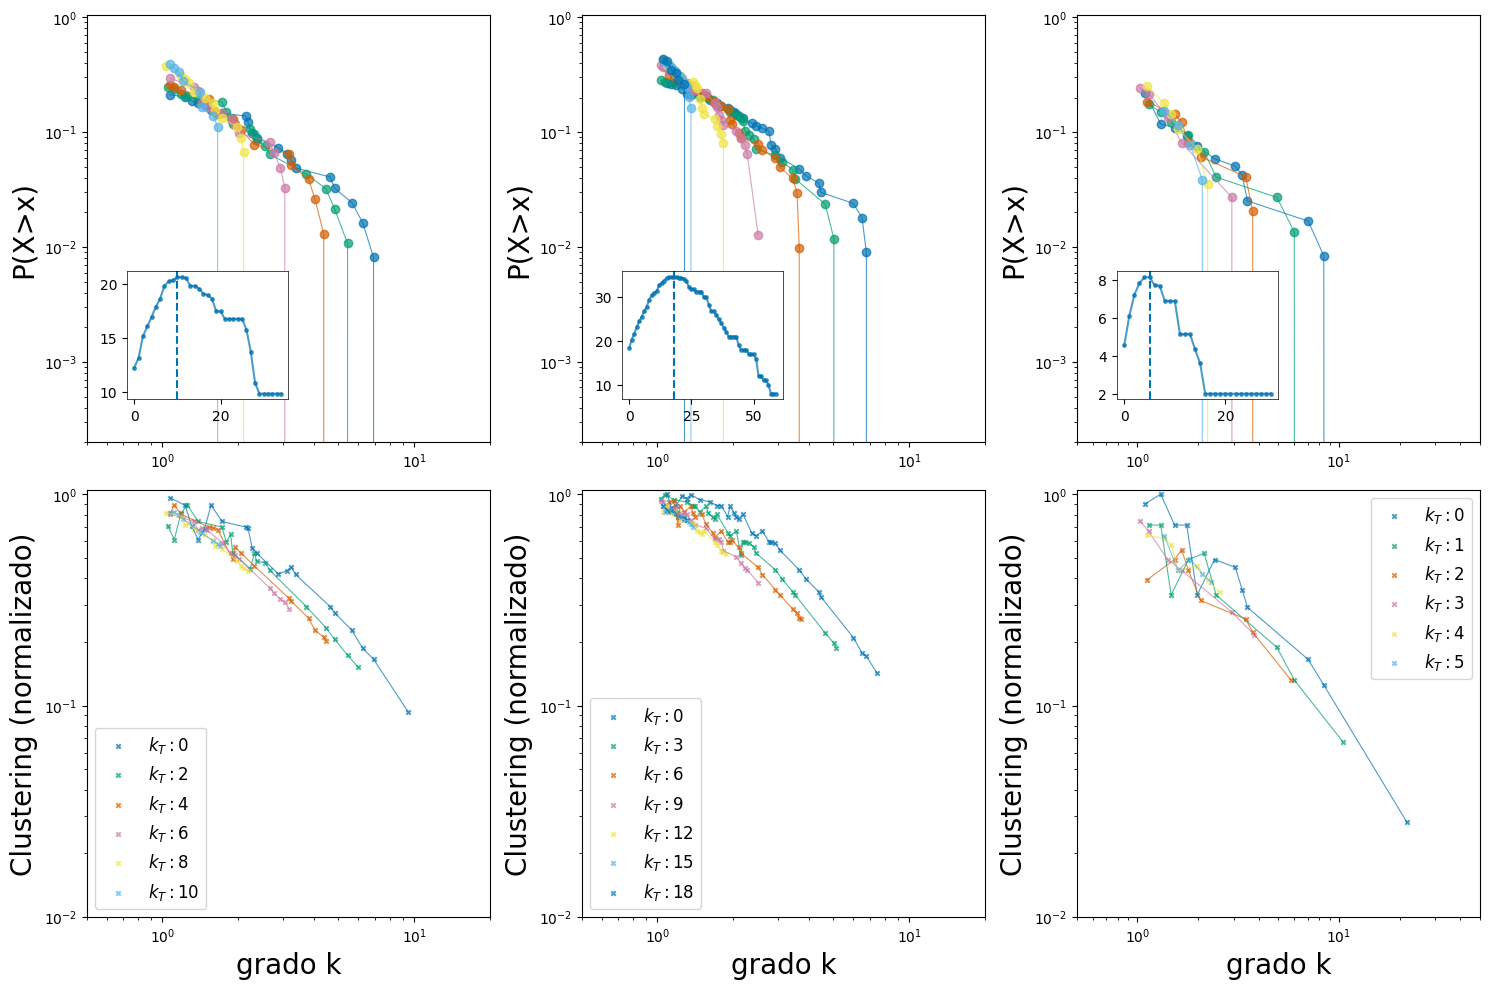

In [27]:
plt.style.use('seaborn-v0_8-colorblind')    

fig, axs = plt.subplots(2, 3)
axs = axs.flat
for ax in axs:  
	ax.set_facecolor("white")
fig.set_size_inches(15,10)

xlim_nat_f_e = (0.5, 20)
xlim_9n_f_e = (0.5, 20)
xlim_ch_f_e = (0.5, 50)

plot_pdf_expbin(axs[0], arr_ccdf_points_nat_f, arr_kt_plot_nat_f,
                aa=1.02, ylabel="P(X>x)", ylim=(0.0002, 1.05), xlim=xlim_nat_f_e,
                marker="o", alpha=0.7, dot_size=6, line=True, normalize=False)
ax0_inset = axs[0].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax0_inset, dict_hora_nat_f, limit_kt_nat_f, axvline=critical_kt_nat_f)

plot_pdf_expbin(axs[1], arr_ccdf_points_9n_f, arr_kt_plot_9n_f,
                aa=1.02, ylabel="P(X>x)", ylim=(0.0002, 1.05), xlim=xlim_9n_f_e,
                marker="o", alpha=0.7, dot_size=6, line=True, normalize=False)
ax1_inset = axs[1].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax1_inset, dict_hora_9n_f, limit_kt_9n_f, axvline=critical_kt_9n_f)

plot_pdf_expbin(axs[2], arr_ccdf_points_ch_f, arr_kt_plot_ch_f,
                aa=1.02, ylabel="P(X>x)", ylim=(0.0002, 1.05), xlim=xlim_ch_f_e,
                marker="o", alpha=0.7, dot_size=6, line=True, normalize=False)
ax2_inset = axs[2].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax2_inset, dict_hora_ch_f, limit_kt_ch_f, axvline=critical_kt_ch_f)


plot_clust_ss_expbin(axs[3], arr_kt_plot_nat_f, dict_norm_int_deg_nat_f,
                     aa=1.02, xlim=xlim_nat_f_e, ylim=(0.01, 1.05),
                     alpha=0.7, marker="x", linewidth=0.8, s=10,
                     ylabel="Clustering (normalizado)", xlabel="grado k")

plot_clust_ss_expbin(axs[4], arr_kt_plot_9n_f, dict_norm_int_deg_9n_f,
                     aa=1.02, xlim=xlim_9n_f_e, ylim=(0.01, 1.05),
                     alpha=0.7, marker="x", linewidth=0.8, s=10,
                     ylabel="Clustering (normalizado)", xlabel="grado k")

plot_clust_ss_expbin(axs[5], arr_kt_plot_ch_f, dict_norm_int_deg_ch_f,
                     aa=1.02, xlim=xlim_ch_f_e, ylim=(0.01, 1.05),
                     alpha=0.7, marker="x", linewidth=0.8, s=10,
                     ylabel="Clustering (normalizado)", xlabel="grado k")


plt.tight_layout()
plt.savefig(plots_folder + "self_sim_exponential_filtered.png")
plt.show()